# Sistem Peringatan Dini Risiko Karhutla Kalimantan Timur Berbasis Logika Fuzzy Mamdani

Notebook ini membangun sistem fuzzy Mamdani untuk menghitung skor risiko kebakaran hutan dan lahan (karhutla) harian di Kalimantan Timur, lalu memvalidasinya dengan data titik panas NASA FIRMS.

**Data yang digunakan:**
- Data cuaca harian 52 titik grid, 1 Januari 2019 sampai 20 September 2026 (Open-Meteo, ERA5), hasil dari notebook pengambilan data
- Data titik panas NASA FIRMS yang sudah dibersihkan, sebagai data validasi

In [2]:
# cek lokasi file input
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/riyadiofishrau/cuaca-kaltim-2019-2026/cuaca_kaltim_2019_2026.csv
/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/gadm41_IDN_2.json
/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/titik_bandel.csv
/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/titik_panas_kaltim_bersih.csv
/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/titik_panas_kaltim.csv
/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/idn2/gadm41_IDN_2.json


## A. Persiapan

### A1. Memuat Library
Memuat library yang dibutuhkan untuk pengolahan data dan visualisasi.

In [3]:
# import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### A2. Memuat Data Cuaca
Memuat data cuaca harian hasil pengambilan dari Open-Meteo. Data ini berisi suhu maksimum, kelembapan minimum, curah hujan, kecepatan angin maksimum, dan hari tanpa hujan untuk setiap titik grid.

In [4]:
# baca data cuaca
PATH_CUACA = "/kaggle/input/datasets/riyadiofishrau/cuaca-kaltim-2019-2026/cuaca_kaltim_2019_2026.csv"
cuaca = pd.read_csv(PATH_CUACA, parse_dates=["tanggal"])

print(cuaca.shape)
print(cuaca["tanggal"].min().date(), "sampai", cuaca["tanggal"].max().date())
print(cuaca["id"].nunique(), "titik grid")
cuaca.head()

(146640, 10)
2019-01-01 sampai 2026-09-20
52 titik grid


,tanggal,suhu,kelembapan,hujan,angin,id,lat,lon,kabupaten,hari_tanpa_hujan
0,2019-01-01,28.7,79,6.5,6.1,0,-2.0,116.0,Paser,0
1,2019-01-02,28.8,77,13.2,7.8,0,-2.0,116.0,Paser,0
2,2019-01-03,30.7,70,7.2,6.4,0,-2.0,116.0,Paser,0
3,2019-01-04,29.5,77,9.1,6.4,0,-2.0,116.0,Paser,0
4,2019-01-05,31.8,61,7.4,6.6,0,-2.0,116.0,Paser,0


## B. Eksplorasi Data

### B1. Pola Bulanan Cuaca
Menampilkan rata-rata setiap variabel cuaca per bulan dari seluruh titik grid dan seluruh tahun. Grafik ini menunjukkan kapan Kalimantan Timur mengalami kondisi paling kering, yang biasanya bertepatan dengan musim kebakaran.

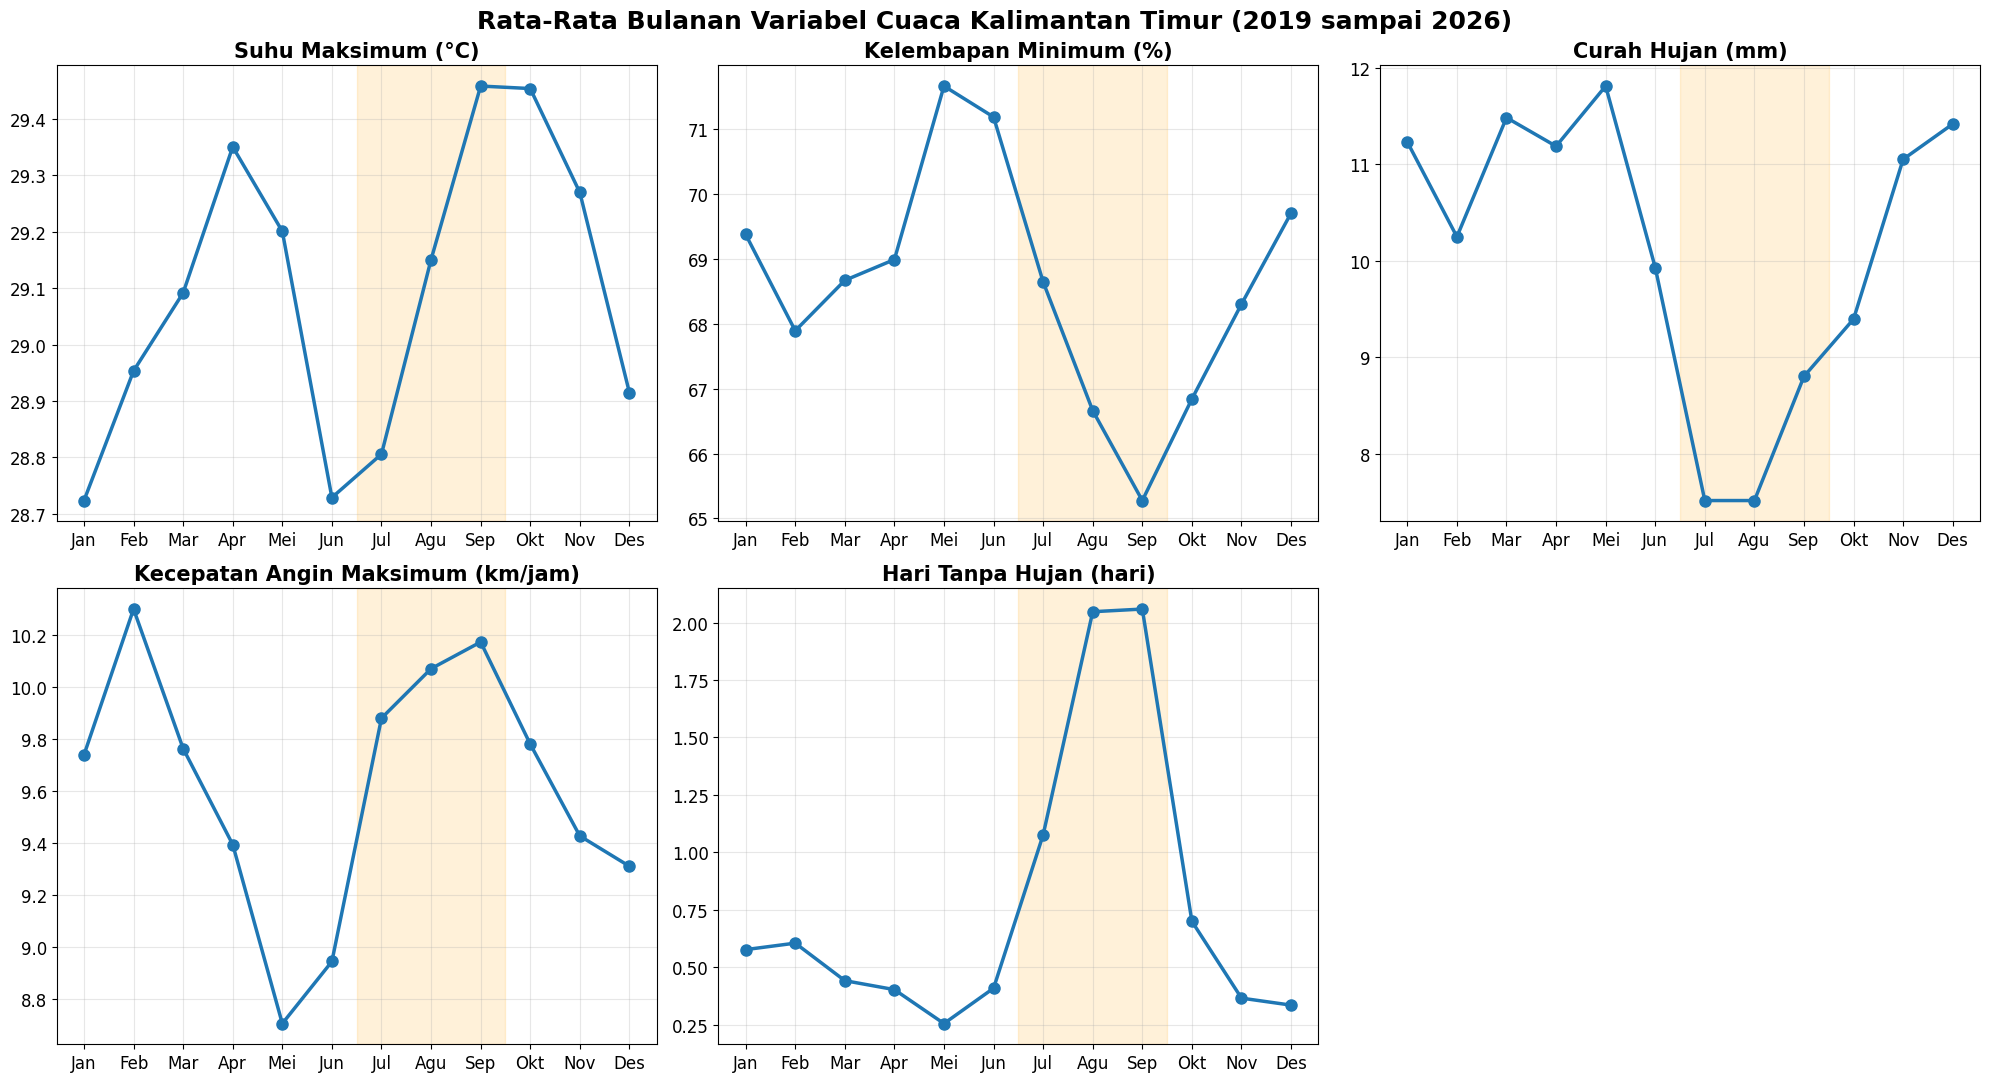

In [5]:
# rata2 tiap variabel per bulan (versi besar)
cuaca["bulan"] = cuaca["tanggal"].dt.month
variabel = ["suhu", "kelembapan", "hujan", "angin", "hari_tanpa_hujan"]
judul = ["Suhu Maksimum (°C)", "Kelembapan Minimum (%)", "Curah Hujan (mm)",
         "Kecepatan Angin Maksimum (km/jam)", "Hari Tanpa Hujan (hari)"]
nama_bulan = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

bulanan = cuaca.groupby("bulan")[variabel].mean()

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for ax, v, j in zip(axes, variabel, judul):
    ax.plot(bulanan.index, bulanan[v], marker="o", linewidth=2.5, markersize=8)
    ax.axvspan(6.5, 9.5, color="orange", alpha=0.15)
    ax.set_title(j, fontsize=15, fontweight="bold")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(nama_bulan, fontsize=12)
    ax.tick_params(axis="y", labelsize=12)
    ax.grid(alpha=0.3)
axes[5].axis("off")

fig.suptitle("Rata-Rata Bulanan Variabel Cuaca Kalimantan Timur (2019 sampai 2026)",
             fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Hasil B1:**
Pola bulanan menunjukkan bahwa periode Juli sampai September merupakan periode paling kering di Kalimantan Timur. Curah hujan mencapai titik terendah pada Juli sampai Agustus, sementara hari tanpa hujan meningkat tajam pada Agustus sampai September hingga sekitar empat kali lipat dibanding bulan basah. Pada periode yang sama, kelembapan minimum mencapai titik terendah (September), sedangkan suhu maksimum dan kecepatan angin cenderung tinggi.

Kombinasi kondisi tersebut menjadikan Agustus sampai September sebagai periode dengan potensi risiko kebakaran paling tinggi. Selisih nilai rata-rata bulanan relatif kecil karena merupakan hasil rata-rata dari 52 titik dan delapan tahun, sehingga batas fungsi keanggotaan fuzzy akan ditentukan berdasarkan sebaran data harian, bukan rata-rata bulanan.

### B2. Sebaran Data Harian
Menampilkan sebaran nilai harian setiap variabel beserta persentilnya. Persentil menunjukkan batas nilai untuk sekian persen data, misalnya P90 berarti 90% hari memiliki nilai di bawah angka tersebut. Informasi ini digunakan sebagai salah satu dasar penentuan batas fungsi keanggotaan fuzzy, bersama dengan rujukan dari penelitian sebelumnya.

In [6]:
# tabel persentil tiap variabel
persen = cuaca[variabel].quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]).T.round(1)
persen.columns = ["P5", "P10", "P25", "P50", "P75", "P90", "P95"]
persen

,P5,P10,P25,P50,P75,P90,P95
suhu,23.8,25.6,27.9,29.5,30.8,31.8,32.4
kelembapan,54.0,57.0,63.0,69.0,74.0,80.0,84.0
hujan,0.2,0.7,2.7,7.5,14.6,22.7,28.6
angin,5.5,6.2,7.4,9.0,11.2,13.6,15.5
hari_tanpa_hujan,0.0,0.0,0.0,0.0,1.0,2.0,4.0


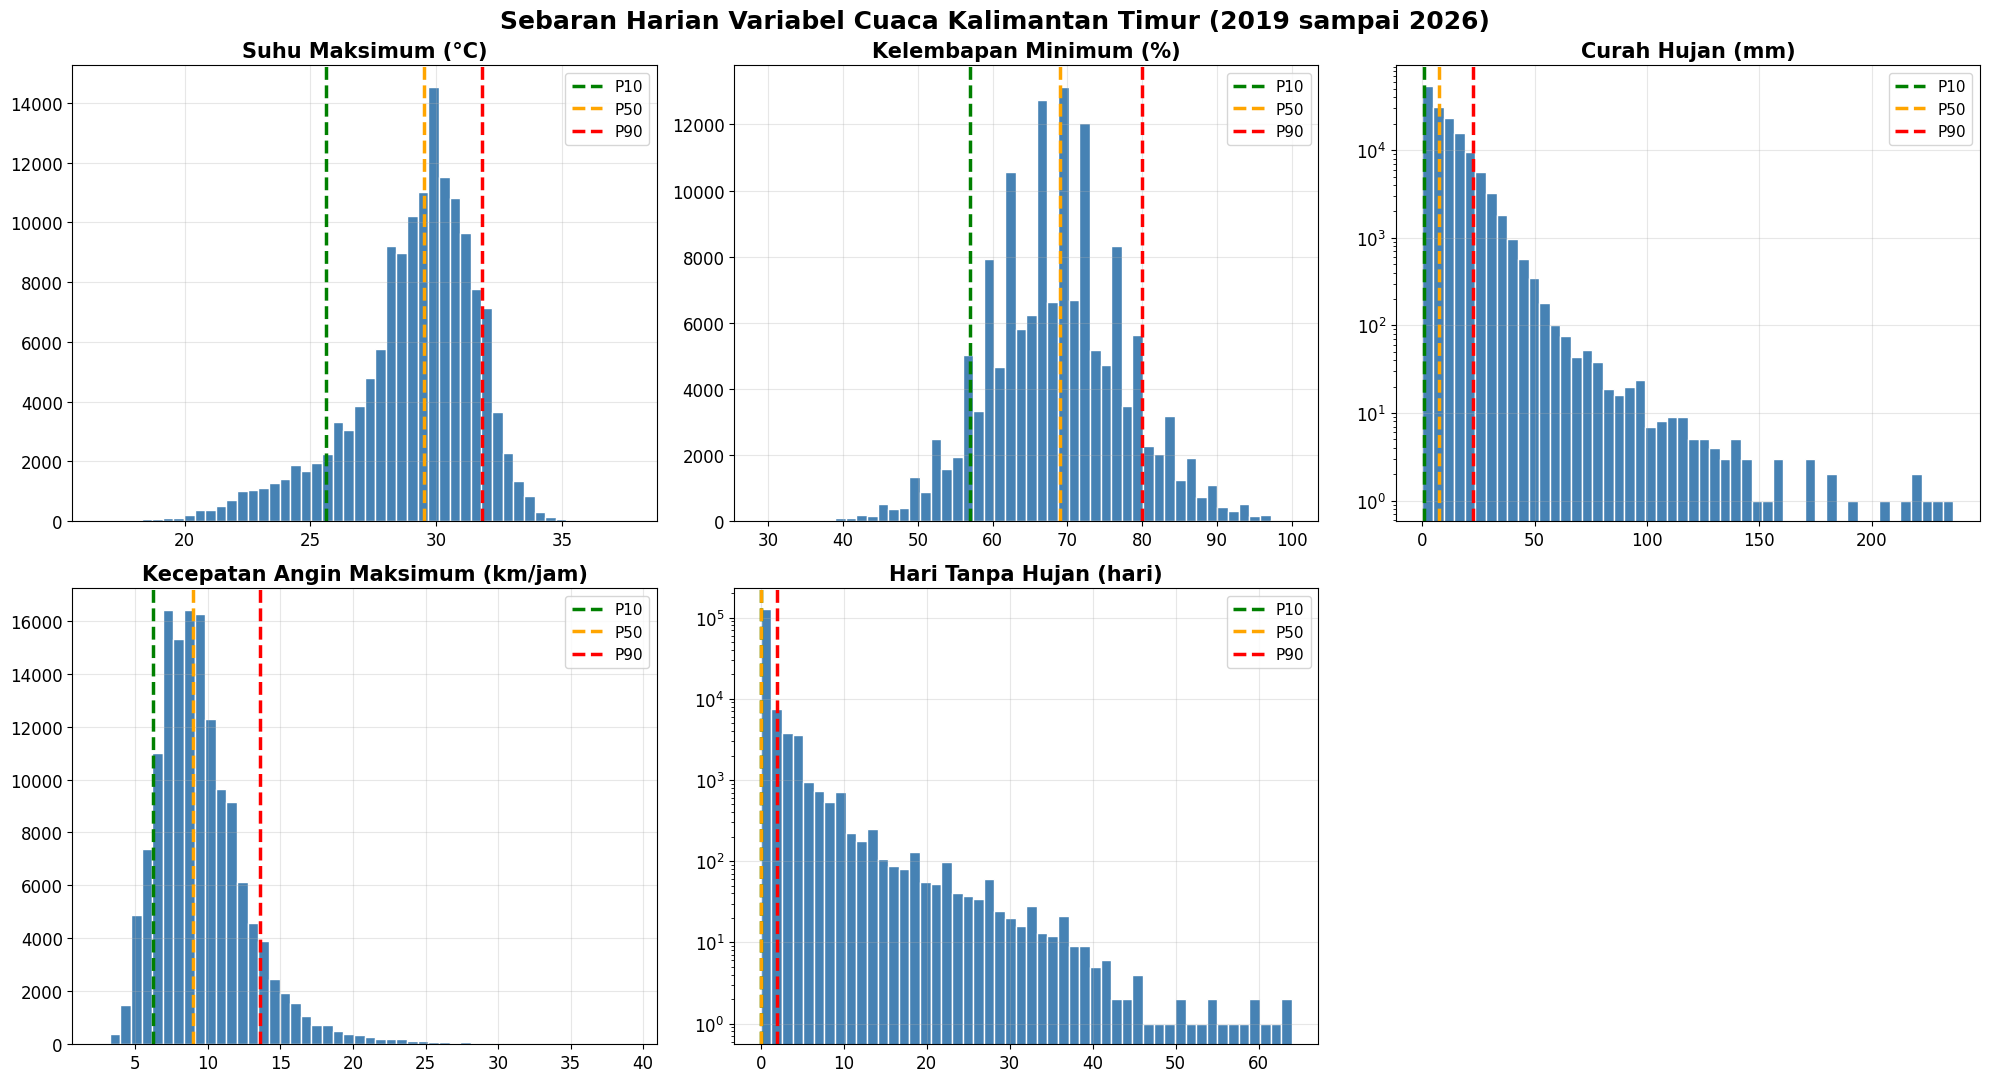

In [7]:
# histogram sebaran harian + garis persentil
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for ax, v, j in zip(axes, variabel, judul):
    ax.hist(cuaca[v], bins=50, color="steelblue", edgecolor="white")
    for p, warna in [(0.10, "green"), (0.50, "orange"), (0.90, "red")]:
        ax.axvline(cuaca[v].quantile(p), color=warna, linestyle="--", linewidth=2.5, label=f"P{int(p*100)}")
    if v in ["hujan", "hari_tanpa_hujan"]:
        ax.set_yscale("log")
    ax.set_title(j, fontsize=15, fontweight="bold")
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
axes[5].axis("off")

fig.suptitle("Sebaran Harian Variabel Cuaca Kalimantan Timur (2019 sampai 2026)",
             fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

**Hasil B2:**
- **Suhu maksimum** memiliki sebaran yang condong ke kiri. Sebagian besar hari berada di sekitar 28 sampai 32 °C, sedangkan ekor panjang ke arah suhu rendah berasal dari hari-hari hujan atau berawan. Nilai P10, P50, dan P90 berturut-turut sekitar 25,6; 29,5; dan 31,8 °C.
- **Kelembapan minimum** memiliki sebaran yang mendekati normal dengan nilai P10, P50, dan P90 sekitar 57, 69, dan 80 %. Nilai di bawah 50 % sangat jarang terjadi karena data ERA5 merupakan nilai rata-rata area grid, sehingga lebih halus dibanding pengukuran stasiun.
- **Curah hujan** sangat condong ke kanan. Sebagian besar hari memiliki curah hujan kecil, sedangkan hujan ekstrem di atas 100 mm hanya terjadi sesekali.
- **Kecepatan angin maksimum** sedikit condong ke kanan, dengan sebagian besar nilai berada di antara 6 dan 14 km/jam.
- **Hari tanpa hujan** sangat condong ke nol. Nilai P10 dan P50 sama-sama 0 dan P90 hanya sekitar 2 hari, meskipun periode kering panjang hingga lebih dari 60 hari tetap tercatat.

Berdasarkan pola tersebut, batas fungsi keanggotaan ditentukan secara hybrid. Suhu, kelembapan, curah hujan, dan kecepatan angin menggunakan persentil data harian agar sesuai dengan karakteristik data ERA5. Hari tanpa hujan menggunakan kategori resmi BMKG (5, 10, dan 20 hari), karena persentilnya tidak mampu membedakan kondisi kering pendek dan panjang.

## C. Perancangan Fungsi Keanggotaan

### C1. Memuat Library Fuzzy
Memasang dan memuat scikit-fuzzy, library Python untuk membangun himpunan fuzzy dan fungsi keanggotaan.

# install + import scikit-fuzzy
!pip install -q scikit-fuzzy
import skfuzzy as fuzz

In [8]:
# install + import scikit-fuzzy
!pip install -q scikit-fuzzy
import skfuzzy as fuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.4 MB/s eta 0:00:0000:010:01


### C2. Menentukan Batas Fungsi Keanggotaan
Batas ditentukan secara hybrid sesuai hasil B2:
- Suhu, kelembapan, dan kecepatan angin menggunakan P10, P50, dan P90 data harian
- Curah hujan menggunakan ambang 3 mm (sama dengan ambang hari tanpa hujan), P50, dan P90
- Hari tanpa hujan menggunakan kategori BMKG: 5, 10, dan 20 hari

In [9]:
# batas tiap variabel (hybrid: persentil + BMKG)
batas = {
    "suhu": tuple(persen.loc["suhu", ["P10", "P50", "P90"]]),
    "kelembapan": tuple(persen.loc["kelembapan", ["P10", "P50", "P90"]]),
    "hujan": (3, persen.loc["hujan", "P50"], persen.loc["hujan", "P90"]),
    "angin": tuple(persen.loc["angin", ["P10", "P50", "P90"]]),
    "hari_tanpa_hujan": (5, 10, 20),
}
pd.DataFrame(batas, index=["batas bawah", "tengah", "batas atas"]).T

,batas bawah,tengah,batas atas
suhu,25.6,29.5,31.8
kelembapan,57.0,69.0,80.0
hujan,3.0,7.5,22.7
angin,6.2,9.0,13.6
hari_tanpa_hujan,5.0,10.0,20.0


### C3. Membuat Fungsi Keanggotaan
Setiap variabel dibagi menjadi tiga himpunan fuzzy. Himpunan tengah berbentuk segitiga, sedangkan dua himpunan di ujung berbentuk trapesium agar nilai yang sangat rendah atau sangat tinggi tetap memiliki derajat keanggotaan penuh.

In [10]:
# semesta pembicaraan + label + fungsi keanggotaan tiap variabel
semesta = {
    "suhu": np.arange(15, 40.1, 0.1),
    "kelembapan": np.arange(20, 100.1, 0.5),
    "hujan": np.arange(0, 250.1, 0.5),
    "angin": np.arange(0, 40.1, 0.1),
    "hari_tanpa_hujan": np.arange(0, 70.1, 0.5),
}
label = {
    "suhu": ["rendah", "sedang", "tinggi"],
    "kelembapan": ["kering", "sedang", "lembap"],
    "hujan": ["rendah", "sedang", "tinggi"],
    "angin": ["pelan", "sedang", "kencang"],
    "hari_tanpa_hujan": ["pendek", "menengah", "panjang"],
}

mf = {}
for v in variabel:
    u = semesta[v]
    a, b, c = batas[v]
    mf[v] = {
        label[v][0]: fuzz.trapmf(u, [u[0], u[0], a, b]),
        label[v][1]: fuzz.trimf(u, [a, b, c]),
        label[v][2]: fuzz.trapmf(u, [b, c, u[-1], u[-1]]),
    }

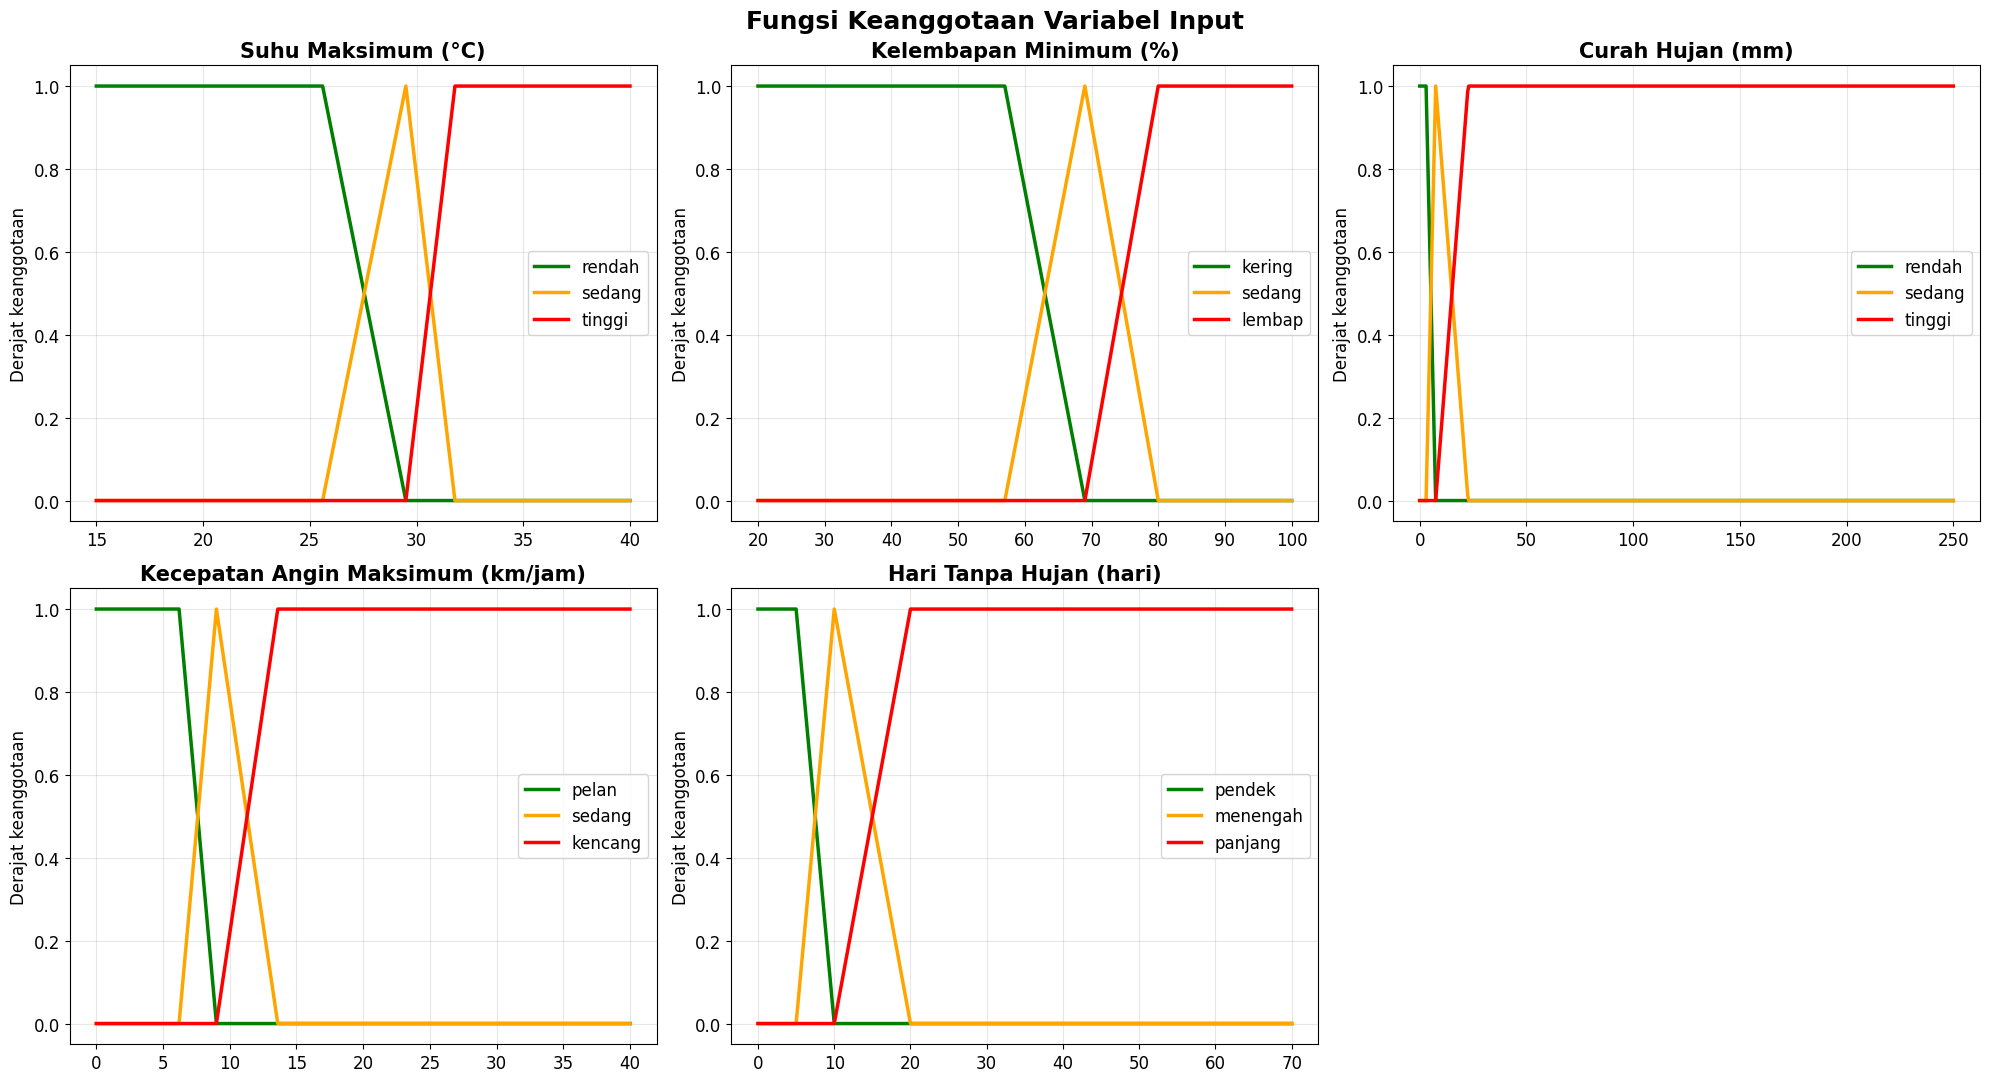

In [11]:
# grafik fungsi keanggotaan
warna = ["green", "orange", "red"]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()
for ax, v, j in zip(axes, variabel, judul):
    for lab, w in zip(label[v], warna):
        ax.plot(semesta[v], mf[v][lab], color=w, linewidth=2.5, label=lab)
    ax.set_title(j, fontsize=15, fontweight="bold")
    ax.set_ylabel("Derajat keanggotaan", fontsize=12)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
axes[5].axis("off")

fig.suptitle("Fungsi Keanggotaan Variabel Input", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

### C4. Fuzzifikasi
Mengubah nilai asli setiap variabel menjadi derajat keanggotaan pada ketiga himpunan fuzzy. Contohnya, kelembapan 60 % bisa bernilai 0,75 "kering" dan 0,25 "sedang" sekaligus.

In [12]:
# hitung derajat keanggotaan semua baris data
derajat = {}
for v in variabel:
    derajat[v] = {}
    for lab in label[v]:
        derajat[v][lab] = fuzz.interp_membership(semesta[v], mf[v][lab], cuaca[v].values)

contoh = cuaca.iloc[[0]][variabel]
print(contoh.to_string(index=False))
for v in variabel:
    print(v, {lab: round(derajat[v][lab][0], 2) for lab in label[v]})

 suhu  kelembapan  hujan  angin  hari_tanpa_hujan
 28.7          79    6.5    6.1                 0
suhu {'rendah': np.float64(0.21), 'sedang': np.float64(0.79), 'tinggi': np.float64(0.0)}
kelembapan {'kering': np.float64(0.0), 'sedang': np.float64(0.09), 'lembap': np.float64(0.91)}
hujan {'rendah': np.float64(0.22), 'sedang': np.float64(0.78), 'tinggi': np.float64(0.0)}
angin {'pelan': np.float64(1.0), 'sedang': np.float64(0.0), 'kencang': np.float64(0.0)}
hari_tanpa_hujan {'pendek': np.float64(1.0), 'menengah': np.float64(0.0), 'panjang': np.float64(0.0)}


## D. Basis Aturan dan Inferensi Mamdani

Sistem disusun bertingkat:
1. **Indeks Kekeringan** dari curah hujan dan hari tanpa hujan (9 aturan)
2. **Indeks Cuaca Api** dari suhu, kelembapan, dan kecepatan angin (27 aturan)
3. **Skor Risiko Karhutla** dari kedua indeks tersebut (9 aturan)

Total terdapat 45 aturan. Aturan disusun dengan prinsip skor: setiap himpunan diberi skor 0, 1, atau 2 sesuai tingkat bahayanya, lalu jumlah skor menentukan kategori output. Cara ini membuat aturan konsisten dan mudah ditelusuri.

### D1. Himpunan Fuzzy Output
Indeks kekeringan dan indeks cuaca api memiliki tiga himpunan (rendah, sedang, tinggi) pada rentang 0 sampai 100. Skor risiko memiliki empat himpunan (rendah, sedang, tinggi, sangat tinggi).

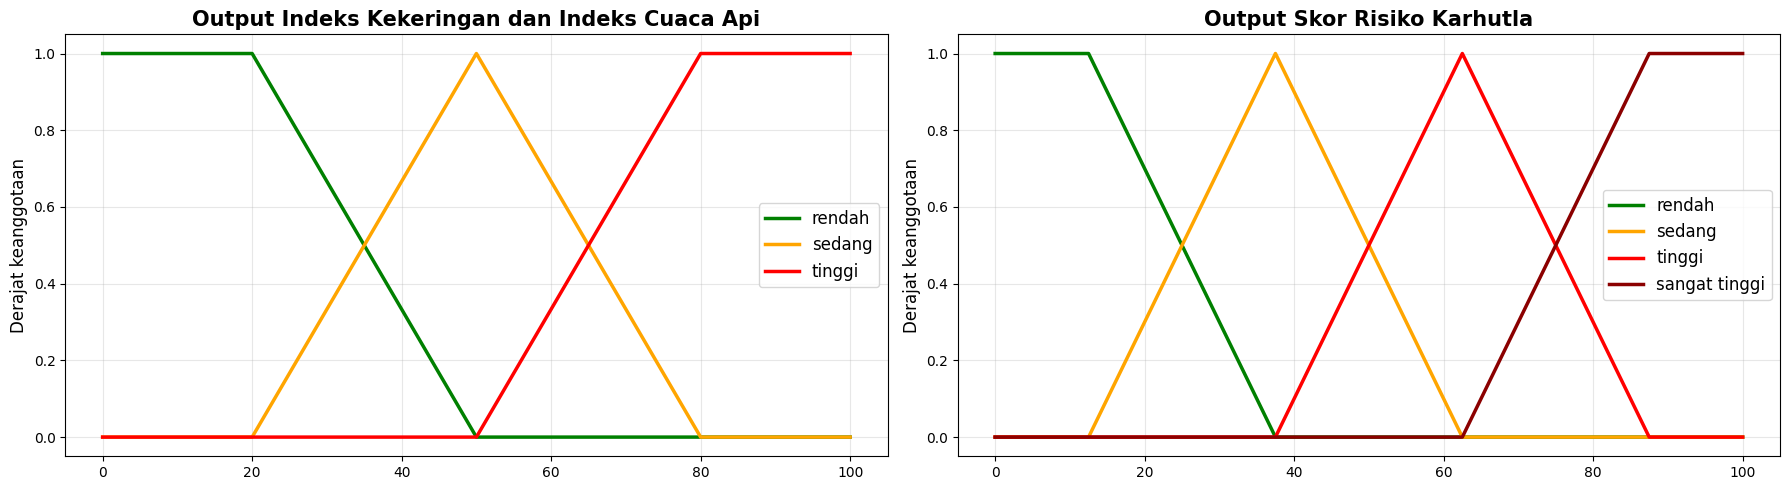

In [13]:
# himpunan output 3 kelas dan 4 kelas
u_out = np.arange(0, 100.1, 0.5)
mf_3 = {
    "rendah": fuzz.trapmf(u_out, [0, 0, 20, 50]),
    "sedang": fuzz.trimf(u_out, [20, 50, 80]),
    "tinggi": fuzz.trapmf(u_out, [50, 80, 100, 100]),
}
mf_4 = {
    "rendah": fuzz.trapmf(u_out, [0, 0, 12.5, 37.5]),
    "sedang": fuzz.trimf(u_out, [12.5, 37.5, 62.5]),
    "tinggi": fuzz.trimf(u_out, [37.5, 62.5, 87.5]),
    "sangat tinggi": fuzz.trapmf(u_out, [62.5, 87.5, 100, 100]),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for lab, w in zip(mf_3, ["green", "orange", "red"]):
    axes[0].plot(u_out, mf_3[lab], color=w, linewidth=2.5, label=lab)
for lab, w in zip(mf_4, ["green", "orange", "red", "darkred"]):
    axes[1].plot(u_out, mf_4[lab], color=w, linewidth=2.5, label=lab)
axes[0].set_title("Output Indeks Kekeringan dan Indeks Cuaca Api", fontsize=15, fontweight="bold")
axes[1].set_title("Output Skor Risiko Karhutla", fontsize=15, fontweight="bold")
for ax in axes:
    ax.set_ylabel("Derajat keanggotaan", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### D2. Fungsi Inferensi Mamdani
Fungsi ini menjalankan tiga tahap Mamdani untuk seluruh data sekaligus:
1. **Implikasi**: kekuatan setiap aturan dihitung dengan operator MIN dari derajat keanggotaan bagian IF, lalu himpunan output dipotong setinggi kekuatan tersebut
2. **Agregasi**: seluruh hasil potongan digabung dengan operator MAX
3. **Defuzzifikasi**: hasil gabungan diubah menjadi satu angka dengan metode centroid (titik berat)

In [14]:
# fungsi inferensi mamdani (MIN, MAX, centroid)
from itertools import product

def mamdani(aturan, mf_keluar):
    n = len(aturan[0][0][0])
    agregasi = np.zeros((n, len(u_out)), dtype=np.float32)
    for anteseden, keluar in aturan:
        kekuatan = np.minimum.reduce(anteseden).astype(np.float32)
        klip = np.minimum(kekuatan[:, None], mf_keluar[keluar][None, :].astype(np.float32))
        agregasi = np.maximum(agregasi, klip)
    return (agregasi * u_out).sum(axis=1) / (agregasi.sum(axis=1) + 1e-9)

### D3. Tingkat 1: Indeks Kekeringan
Skor bahaya: curah hujan tinggi = 0, sedang = 1, rendah = 2; hari tanpa hujan pendek = 0, menengah = 1, panjang = 2. Jumlah skor 0 sampai 1 menjadi kekeringan rendah, 2 menjadi sedang, dan 3 sampai 4 menjadi tinggi.

In [15]:
# 9 aturan kekeringan + hitung indeksnya
skor_hujan = {"tinggi": 0, "sedang": 1, "rendah": 2}
skor_hth = {"pendek": 0, "menengah": 1, "panjang": 2}

aturan_kering, tabel = [], []
for h, t in product(label["hujan"], label["hari_tanpa_hujan"]):
    s = skor_hujan[h] + skor_hth[t]
    keluar = "rendah" if s <= 1 else ("sedang" if s == 2 else "tinggi")
    aturan_kering.append(([derajat["hujan"][h], derajat["hari_tanpa_hujan"][t]], keluar))
    tabel.append([h, t, s, keluar])

cuaca["indeks_kekeringan"] = mamdani(aturan_kering, mf_3)
pd.DataFrame(tabel, columns=["curah hujan", "hari tanpa hujan", "skor", "kekeringan"])

,curah hujan,hari tanpa hujan,skor,kekeringan
0,rendah,pendek,2,sedang
1,rendah,menengah,3,tinggi
2,rendah,panjang,4,tinggi
3,sedang,pendek,1,rendah
4,sedang,menengah,2,sedang
5,sedang,panjang,3,tinggi
6,tinggi,pendek,0,rendah
7,tinggi,menengah,1,rendah
8,tinggi,panjang,2,sedang


### D4. Tingkat 1: Indeks Cuaca Api
Skor bahaya: suhu rendah = 0, sedang = 1, tinggi = 2; kelembapan lembap = 0, sedang = 1, kering = 2; angin pelan = 0, sedang = 1, kencang = 2. Jumlah skor 0 sampai 2 menjadi cuaca api rendah, 3 menjadi sedang, dan 4 sampai 6 menjadi tinggi.

In [16]:
# 27 aturan cuaca api + hitung indeksnya
skor_suhu = {"rendah": 0, "sedang": 1, "tinggi": 2}
skor_lembap = {"lembap": 0, "sedang": 1, "kering": 2}
skor_angin = {"pelan": 0, "sedang": 1, "kencang": 2}

aturan_api, tabel = [], []
for s1, k, a in product(label["suhu"], label["kelembapan"], label["angin"]):
    s = skor_suhu[s1] + skor_lembap[k] + skor_angin[a]
    keluar = "rendah" if s <= 2 else ("sedang" if s == 3 else "tinggi")
    aturan_api.append(([derajat["suhu"][s1], derajat["kelembapan"][k], derajat["angin"][a]], keluar))
    tabel.append([s1, k, a, s, keluar])

cuaca["indeks_cuaca_api"] = mamdani(aturan_api, mf_3)
pd.DataFrame(tabel, columns=["suhu", "kelembapan", "angin", "skor", "cuaca api"])

,suhu,kelembapan,angin,skor,cuaca api
0,rendah,kering,pelan,2,rendah
1,rendah,kering,sedang,3,sedang
2,rendah,kering,kencang,4,tinggi
3,rendah,sedang,pelan,1,rendah
4,rendah,sedang,sedang,2,rendah
5,rendah,sedang,kencang,3,sedang
6,rendah,lembap,pelan,0,rendah
7,rendah,lembap,sedang,1,rendah
8,rendah,lembap,kencang,2,rendah
9,sedang,kering,pelan,3,sedang


### D5. Tingkat 2: Skor Risiko Karhutla
Kedua indeks dari tingkat 1 difuzzifikasi ulang, lalu digabung. Skor bahaya: rendah = 0, sedang = 1, tinggi = 2. Jumlah skor 0 sampai 1 menjadi risiko rendah, 2 sedang, 3 tinggi, dan 4 sangat tinggi.

Skor akhir 0 sampai 100 dikelompokkan menjadi empat kelas: Rendah (0 sampai 25), Sedang (25 sampai 50), Tinggi (50 sampai 75), dan Sangat Tinggi (75 sampai 100).

In [17]:
# 9 aturan risiko + skor dan kelas akhir
d_kering = {lab: fuzz.interp_membership(u_out, mf_3[lab], cuaca["indeks_kekeringan"].values) for lab in mf_3}
d_api = {lab: fuzz.interp_membership(u_out, mf_3[lab], cuaca["indeks_cuaca_api"].values) for lab in mf_3}
skor_3 = {"rendah": 0, "sedang": 1, "tinggi": 2}
kelas_4 = {0: "rendah", 1: "rendah", 2: "sedang", 3: "tinggi", 4: "sangat tinggi"}

aturan_risiko, tabel = [], []
for kr, ap in product(mf_3, mf_3):
    s = skor_3[kr] + skor_3[ap]
    aturan_risiko.append(([d_kering[kr], d_api[ap]], kelas_4[s]))
    tabel.append([kr, ap, s, kelas_4[s]])

cuaca["skor_risiko"] = mamdani(aturan_risiko, mf_4)
cuaca["kelas_risiko"] = pd.cut(cuaca["skor_risiko"], bins=[0, 25, 50, 75, 100],
                               labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"], include_lowest=True)
pd.DataFrame(tabel, columns=["kekeringan", "cuaca api", "skor", "risiko"])

,kekeringan,cuaca api,skor,risiko
0,rendah,rendah,0,rendah
1,rendah,sedang,1,rendah
2,rendah,tinggi,2,sedang
3,sedang,rendah,1,rendah
4,sedang,sedang,2,sedang
5,sedang,tinggi,3,tinggi
6,tinggi,rendah,2,sedang
7,tinggi,sedang,3,tinggi
8,tinggi,tinggi,4,sangat tinggi


### D6. Pemeriksaan Awal Hasil
Melihat sebaran kelas risiko dan pola skor risiko per bulan serta per tahun. Sistem yang masuk akal seharusnya menghasilkan skor tertinggi pada Agustus sampai September, serta pada tahun kemarau kuat seperti 2019, 2023, dan 2026.

       indeks_kekeringan  indeks_cuaca_api  skor_risiko
count           146640.0          146640.0     146640.0
mean                32.2              50.4         31.0
std                 15.1              20.9         17.7
min                 18.4              18.4         13.4
25%                 19.4              31.7         14.9
50%                 21.3              51.2         26.7
75%                 50.0              68.8         43.7
max                 81.6              81.6         86.6
kelas_risiko
Rendah           47.44
Sedang           33.96
Tinggi           17.29
Sangat Tinggi     1.30
Name: proportion, dtype: float64


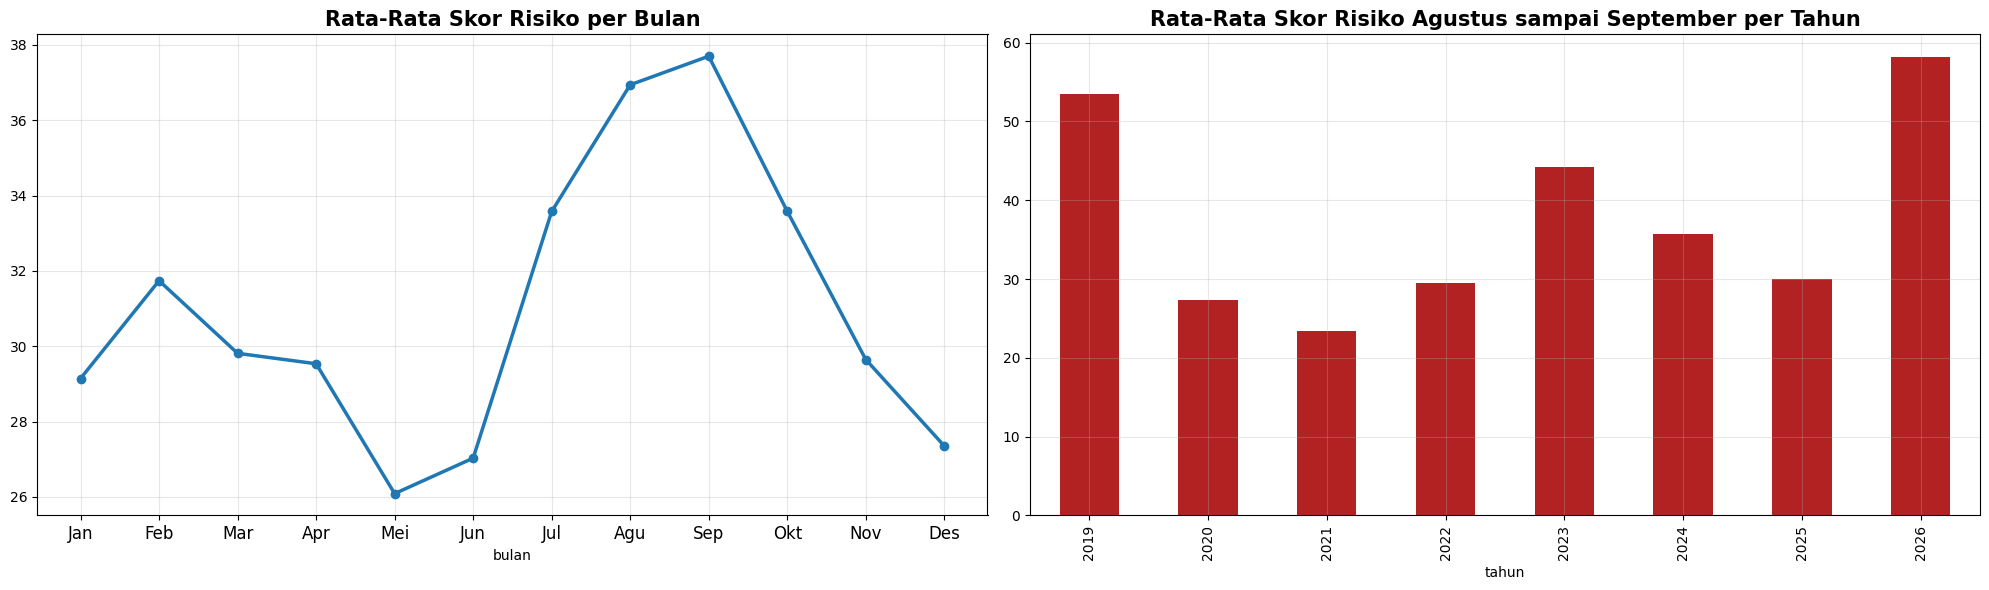

In [18]:
# sebaran kelas + pola bulanan + pola tahunan
print(cuaca[["indeks_kekeringan", "indeks_cuaca_api", "skor_risiko"]].describe().round(1))
print(cuaca["kelas_risiko"].value_counts(normalize=True).mul(100).round(2))

cuaca["tahun"] = cuaca["tanggal"].dt.year
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
cuaca.groupby("bulan")["skor_risiko"].mean().plot(ax=axes[0], marker="o", linewidth=2.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(nama_bulan, fontsize=12)
axes[0].set_title("Rata-Rata Skor Risiko per Bulan", fontsize=15, fontweight="bold")
cuaca[cuaca["bulan"].isin([8, 9])].groupby("tahun")["skor_risiko"].mean().plot(ax=axes[1], kind="bar", color="firebrick")
axes[1].set_title("Rata-Rata Skor Risiko Agustus sampai September per Tahun", fontsize=15, fontweight="bold")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Hasil D6:**
Sistem ini BERHASIL menangkap pola musim kebakaran, padahal belum pernah melihat data titik panas sama sekali.

- **Sebaran kelas:** Rendah 47,44%, Sedang 33,96%, Tinggi 17,29%, dan Sangat Tinggi hanya 1,30%. Hari yang benar-benar berbahaya memang langka, jadi sebaran ini masuk akal.
- **Pola bulanan:** skor risiko tertinggi ada di September (sekitar 37,7) dan Agustus (sekitar 36,9), terendah di Mei. Ini sesuai dengan musim kebakaran di Kalimantan Timur.
- **Pola tahunan (Agustus sampai September):** 2026, 2019, dan 2023 menjadi tiga tahun dengan skor tertinggi, sesuai dengan tahun kemarau kuat. 2021 paling rendah.
- **Catatan:** skor akhir tidak pernah tepat 0 atau 100 (rentang 13,4 sampai 86,6) karena defuzzifikasi centroid selalu merata-ratakan hasil dari banyak aturan.

Semua ini baru pemeriksaan awal. Buktinya baru KUAT kalau dicocokkan dengan titik panas FIRMS di bagian E.

## E. Validasi dengan Titik Panas NASA FIRMS

Sekarang saatnya menguji sistem fuzzy dengan data kenyataan. Idenya: pada hari yang dinilai berisiko TINGGI oleh fuzzy, apakah titik panas benar-benar lebih banyak? Fuzzy tidak pernah dilatih dengan data titik panas, jadi semua data 2019 sampai 2026 boleh dipakai sebagai validasi.

### E1. Memuat Data Titik Panas
Memuat data titik panas Kalimantan Timur yang sudah dibersihkan (kualitas disaring dan titik tambang dibuang), lalu memeriksa isinya.

In [19]:
# cari file firms bersih otomatis lalu baca
import glob
PATH_FIRMS = glob.glob("/kaggle/input/**/titik_panas_kaltim_bersih.csv", recursive=True)[0]
firms = pd.read_csv(PATH_FIRMS)

print(PATH_FIRMS)
print(firms.shape)
print(firms.columns.tolist())
firms.head()

/kaggle/input/datasets/riyadiofishrau/titik-panas-kaltim-bersih/titik_panas_kaltim_bersih.csv
(68236, 22)
['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type', 'sumber', 'NAME_2', 'tahun', 'bulan', 'gx', 'gy', 'di_tambang']


/tmp/ipykernel_59/1884951208.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  firms = pd.read_csv(PATH_FIRMS)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,frp,daynight,type,sumber,NAME_2,tahun,bulan,gx,gy,di_tambang
0,0.60985,117.44263,337.31,0.56,0.43,2019-01-01,553,SNPP,SNPP,n,...,7.02,D,0.0,fire_archive_SV-C2_42572.csv,KutaiTimur,2019,1,33555.0,174.0,True
1,0.66484,117.45906,306.68,0.40,0.44,2019-01-03,1756,SNPP,SNPP,n,...,0.78,N,0.0,fire_archive_SV-C2_42572.csv,KutaiTimur,2019,1,33560.0,190.0,True
2,0.61955,117.43695,300.21,0.40,0.44,2019-01-03,1756,SNPP,SNPP,n,...,0.86,N,0.0,fire_archive_SV-C2_42572.csv,KutaiTimur,2019,1,33553.0,177.0,True
3,1.08045,117.67299,303.09,0.39,0.36,2019-01-04,1737,SNPP,SNPP,n,...,0.43,N,0.0,fire_archive_SV-C2_42572.csv,KutaiTimur,2019,1,33621.0,309.0,True
4,0.80713,117.54220,309.51,0.39,0.36,2019-01-04,1737,SNPP,SNPP,n,...,0.61,N,0.0,fire_archive_SV-C2_42572.csv,KutaiTimur,2019,1,33583.0,231.0,True


### E2. Menyaring Data Titik Panas
File titik panas masih berisi 68.236 titik, termasuk titik yang berada di kawasan tambang batu bara. Titik di tambang BUKAN kebakaran hutan, melainkan panas dari tumpukan batu bara dan aktivitas tambang, jadi bisa jadi ALARM PALSU kalau ikut dihitung.

Penyaringan yang dilakukan:
1. Membuang titik yang berada di tambang (`di_tambang`)
2. Mengubah tanggal ke format datetime
3. Memotong data sampai 20 September 2026, supaya periodenya sama dengan data cuaca

In [20]:
# buang titik tambang, samakan periode dengan data cuaca
print(firms["di_tambang"].value_counts())

firms = firms[firms["di_tambang"].astype(str) == "False"].copy()
firms["tanggal"] = pd.to_datetime(firms["acq_date"])
firms = firms[(firms["tanggal"] >= cuaca["tanggal"].min()) & (firms["tanggal"] <= cuaca["tanggal"].max())]

print("titik panas bersih:", len(firms))
print(firms["tanggal"].min().date(), "sampai", firms["tanggal"].max().date())

di_tambang
False    58859
True      9377
Name: count, dtype: int64
titik panas bersih: 57105
2019-01-05 sampai 2026-09-20


### E3. Memasangkan Titik Panas ke Titik Grid Terdekat
Data cuaca punya 52 titik grid, sedangkan titik panas punya koordinat sendiri. Supaya bisa dibandingkan, setiap titik panas dipasangkan ke titik grid TERDEKAT, lalu jaraknya dicek.

Jarak dihitung dengan rumus jarak biasa pada koordinat (selisih lintang dan bujur dikuadratkan). Karena Kalimantan Timur dekat khatulistiwa, cara sederhana ini sudah cukup akurat. Satu derajat kira-kira 111 km.

In [21]:
# pasangkan tiap titik panas ke grid terdekat
grid = cuaca[["id", "lat", "lon"]].drop_duplicates("id").reset_index(drop=True)

sel_lat = firms["latitude"].values[:, None] - grid["lat"].values[None, :]
sel_lon = firms["longitude"].values[:, None] - grid["lon"].values[None, :]
jarak = sel_lat**2 + sel_lon**2

firms["id"] = grid["id"].values[jarak.argmin(axis=1)]
firms["jarak_km"] = np.sqrt(jarak.min(axis=1)) * 111

print(firms["jarak_km"].describe().round(1))
print(firms["id"].nunique(), "titik grid punya titik panas")

count    57105.0
mean        22.3
std          7.9
min          0.1
25%         16.5
50%         23.5
75%         27.8
max         44.6
Name: jarak_km, dtype: float64
48 titik grid punya titik panas


### E3b. Cek Visual Sebaran Titik Panas dan Titik Grid
Memastikan pemasangan titik panas ke grid masuk akal secara peta. Area hijau adalah wilayah Kalimantan Timur per kabupaten, titik ungu adalah 52 titik grid cuaca, dan titik panas diwarnai dari KUNING (lebih dingin) sampai MERAH (paling panas) berdasarkan suhu kecerahan yang diukur satelit.

Titik panas TIDAK menyebar rata. Bagian barat (pedalaman Kutai Barat dan Mahakam Ulu) hampir kosong karena berupa hutan pegunungan yang basah. Titik panas justru MENUMPUK di Kutai Kartanegara, Kutai Timur, Berau, dan Paser, yaitu daerah dengan lahan terbuka, perkebunan, dan gambut.

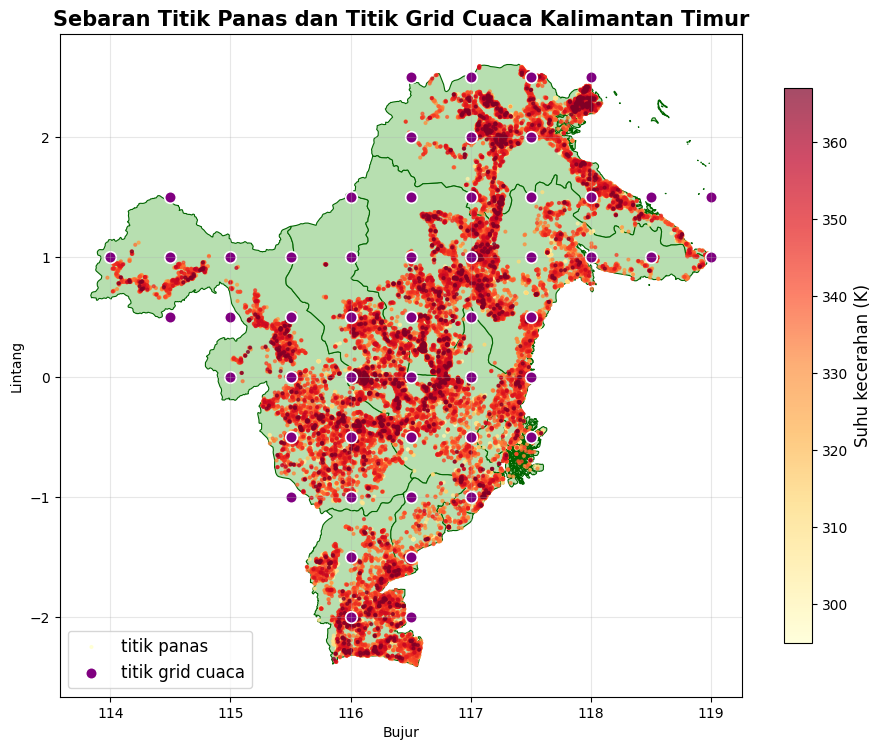

In [22]:
# peta kaltim hijau + titik panas kuning ke merah + grid ungu
import geopandas as gpd
PATH_GADM = glob.glob("/kaggle/input/**/gadm41_IDN_2.json", recursive=True)[0]
kaltim = gpd.read_file(PATH_GADM).query("NAME_1 == 'KalimantanTimur'")
urut = firms.sort_values("brightness")

fig, ax = plt.subplots(figsize=(11, 12))
kaltim.plot(ax=ax, color="#b7dfb0", edgecolor="darkgreen", linewidth=0.8)
titik = ax.scatter(urut["longitude"], urut["latitude"], c=urut["brightness"], cmap="YlOrRd",
                   s=4, alpha=0.7, label="titik panas")
ax.scatter(grid["lon"], grid["lat"], s=70, color="purple", edgecolor="white", linewidth=1.2,
           label="titik grid cuaca")
cb = plt.colorbar(titik, ax=ax, shrink=0.6)
cb.set_label("Suhu kecerahan (K)", fontsize=12)
ax.set_title("Sebaran Titik Panas dan Titik Grid Cuaca Kalimantan Timur", fontsize=15, fontweight="bold")
ax.set_xlabel("Bujur")
ax.set_ylabel("Lintang")
ax.set_aspect("equal")
ax.legend(fontsize=12, loc="lower left")
ax.grid(alpha=0.3)
plt.show()

## E. Validasi dengan Titik Panas NASA FIRMS

Validasi dilakukan dengan mencocokkan skor risiko fuzzy di setiap titik grid dan setiap hari dengan jumlah titik panas yang terdeteksi di sekitar titik grid tersebut pada hari yang sama. Karena sistem fuzzy tidak dilatih dengan data, seluruh periode 2019 sampai 2026 dapat digunakan sebagai data validasi.

### E1. Menempelkan Titik Panas ke Titik Grid Terdekat
Setiap titik panas dipasangkan dengan titik grid cuaca yang paling dekat. Jarak maksimum yang wajar sekitar 40 km, yaitu setengah diagonal kotak grid 0,5 derajat.

In [23]:
# pasangkan tiap titik panas ke titik grid terdekat
from scipy.spatial import cKDTree

grid = cuaca[["id", "lat", "lon"]].drop_duplicates().reset_index(drop=True)
pohon = cKDTree(grid[["lat", "lon"]].values)
jarak, posisi = pohon.query(firms[["latitude", "longitude"]].values)

firms["id"] = grid.loc[posisi, "id"].values
firms["jarak_grid_km"] = jarak * 111
firms["tanggal"] = pd.to_datetime(firms["acq_date"])

print(firms["jarak_grid_km"].describe().round(1))
firms[["latitude", "longitude", "tanggal", "id", "jarak_grid_km"]].head()

count    57105.0
mean        22.3
std          7.9
min          0.1
25%         16.5
50%         23.5
75%         27.8
max         44.6
Name: jarak_grid_km, dtype: float64


,latitude,longitude,tanggal,id,jarak_grid_km
13,-0.87093,117.04252,2019-01-05,7,15.084167
19,0.42513,116.82836,2019-01-05,24,20.785711
20,-0.85417,116.92218,2019-01-06,7,18.347713
21,-0.85477,116.91839,2019-01-06,7,18.491396
22,-0.50302,116.18951,2019-01-06,9,21.038281


### E2. Menghitung Jumlah Titik Panas per Titik Grid per Hari
Jumlah titik panas dihitung untuk setiap pasangan titik grid dan tanggal, lalu digabungkan ke tabel skor risiko. Hari tanpa titik panas diberi nilai 0. Kolom `ada_api` bernilai 1 jika ada minimal satu titik panas.

In [24]:
# hitung titik panas per grid per hari, gabung ke tabel cuaca
jumlah = firms.groupby(["id", "tanggal"]).size().rename("jumlah_titik_panas").reset_index()
cuaca = cuaca.drop(columns=["jumlah_titik_panas"], errors="ignore").merge(jumlah, on=["id", "tanggal"], how="left")
cuaca["jumlah_titik_panas"] = cuaca["jumlah_titik_panas"].fillna(0).astype(int)
cuaca["ada_api"] = (cuaca["jumlah_titik_panas"] > 0).astype(int)

print("titik panas tercocokkan:", cuaca["jumlah_titik_panas"].sum(), "dari", len(firms))
print("persen hari-grid ada api:", round(cuaca["ada_api"].mean() * 100, 2))

titik panas tercocokkan: 57105 dari 57105
persen hari-grid ada api: 9.15


### E3. Hubungan Kelas Risiko dengan Kejadian Titik Panas
Jika sistem bekerja dengan baik, persentase hari yang memiliki titik panas seharusnya meningkat dari kelas Rendah ke Sangat Tinggi. Kolom `kali_lipat_vs_rata2` menunjukkan berapa kali lebih sering titik panas muncul di suatu kelas dibanding rata-rata keseluruhan.

In [25]:
# persentase hari ada api per kelas risiko
ringkas = cuaca.groupby("kelas_risiko", observed=True).agg(
    jumlah_hari_grid=("ada_api", "size"),
    persen_ada_api=("ada_api", "mean"),
    rata2_titik_panas=("jumlah_titik_panas", "mean"),
)
ringkas["persen_ada_api"] = (ringkas["persen_ada_api"] * 100).round(2)
ringkas["rata2_titik_panas"] = ringkas["rata2_titik_panas"].round(3)
ringkas["kali_lipat_vs_rata2"] = (ringkas["persen_ada_api"] / (cuaca["ada_api"].mean() * 100)).round(2)
ringkas

,jumlah_hari_grid,persen_ada_api,rata2_titik_panas,kali_lipat_vs_rata2
kelas_risiko,,,,
Rendah,69572,2.88,0.060,0.31
Sedang,49801,8.96,0.258,0.98
Tinggi,25355,23.10,1.166,2.53
Sangat Tinggi,1912,57.22,5.488,6.26


### E4. Visualisasi Hasil Validasi
Grafik kiri menunjukkan persentase hari bertitik panas di setiap kelas risiko. Grafik kanan membandingkan rata-rata skor risiko bulanan dengan jumlah titik panas bulanan sepanjang 2019 sampai 2026. Korelasi Spearman mengukur seberapa searah naik-turunnya kedua deret tersebut.

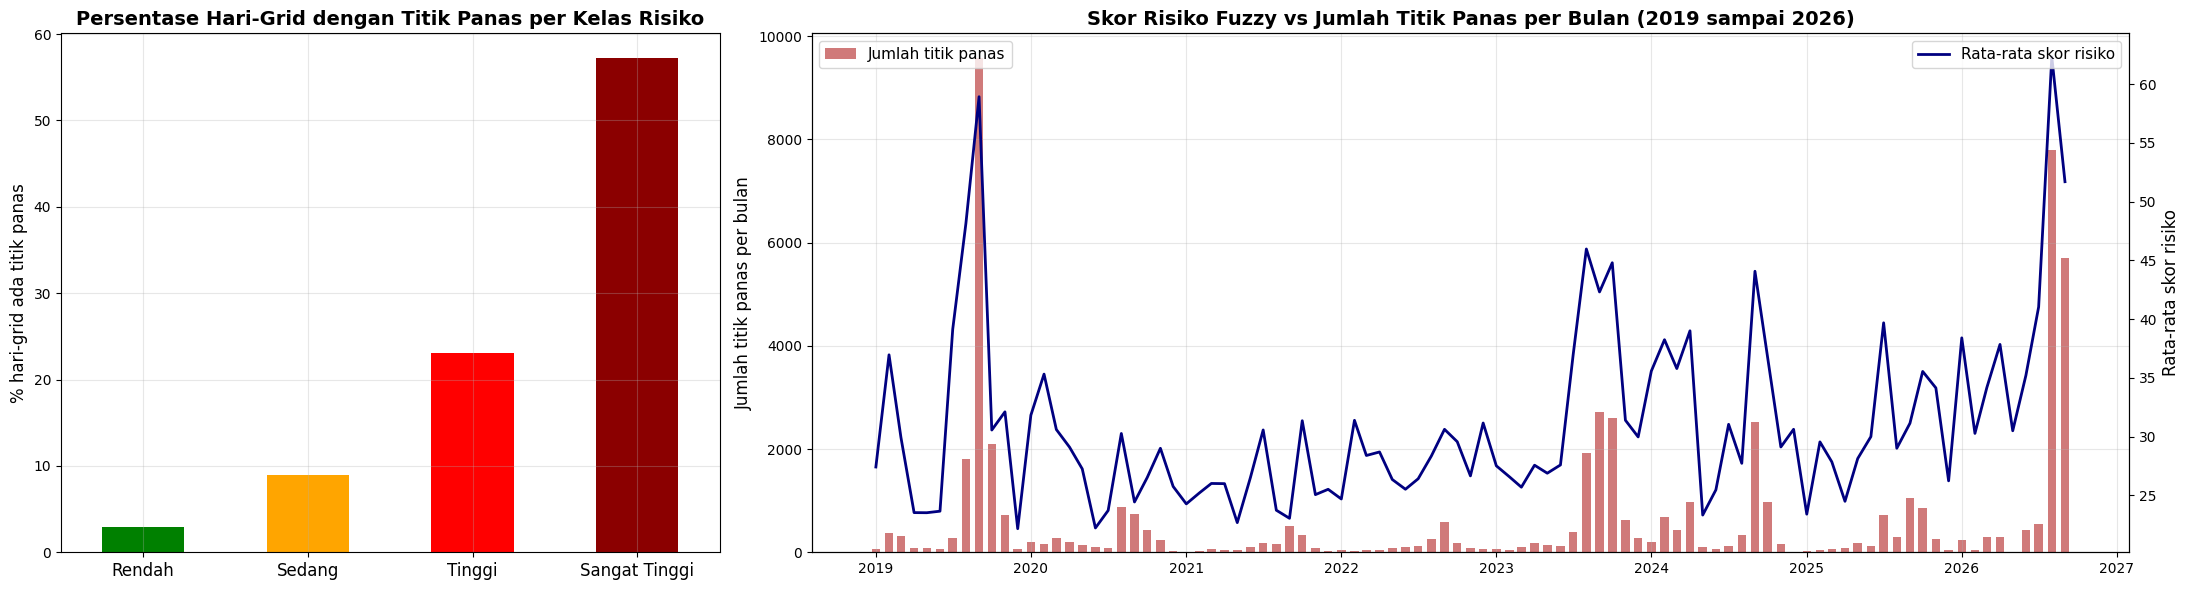

korelasi Spearman bulanan: 0.672


In [26]:
# grafik per kelas + deret waktu bulanan skor vs titik panas
fig, axes = plt.subplots(1, 2, figsize=(22, 6), gridspec_kw={"width_ratios": [1, 2]})
ringkas["persen_ada_api"].plot(ax=axes[0], kind="bar", color=["green", "orange", "red", "darkred"])
axes[0].set_title("Persentase Hari-Grid dengan Titik Panas per Kelas Risiko", fontsize=14, fontweight="bold")
axes[0].set_ylabel("% hari-grid ada titik panas", fontsize=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0, labelsize=12)

bulanan_ts = cuaca.set_index("tanggal").groupby(pd.Grouper(freq="MS")).agg(
    skor=("skor_risiko", "mean"), api=("jumlah_titik_panas", "sum"))
axes[1].bar(bulanan_ts.index, bulanan_ts["api"], width=20, color="firebrick", alpha=0.6, label="Jumlah titik panas")
ax2 = axes[1].twinx()
ax2.plot(bulanan_ts.index, bulanan_ts["skor"], color="navy", linewidth=2, label="Rata-rata skor risiko")
axes[1].set_title("Skor Risiko Fuzzy vs Jumlah Titik Panas per Bulan (2019 sampai 2026)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Jumlah titik panas per bulan", fontsize=12)
ax2.set_ylabel("Rata-rata skor risiko", fontsize=12)
axes[1].legend(loc="upper left", fontsize=11)
ax2.legend(loc="upper right", fontsize=11)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("korelasi Spearman bulanan:", round(bulanan_ts["skor"].corr(bulanan_ts["api"], method="spearman"), 3))

## F. Perbandingan dengan Metode Sederhana

Untuk menguji apakah fuzzy Mamdani memberi nilai tambah, hasilnya dibandingkan dengan dua metode pembanding:
1. **Hari tanpa hujan saja**: skor risiko hanya berdasarkan jumlah hari berturut-turut tanpa hujan
2. **If-else tegas**: menggunakan batas yang sama dengan fuzzy, tetapi tiap kondisi hanya bernilai 0 atau 1. Skor adalah jumlah kondisi berbahaya yang terpenuhi (0 sampai 5): suhu di atas P90, kelembapan di bawah P10, angin di atas P90, hujan di bawah 3 mm, dan hari tanpa hujan minimal 10 hari

### F1. Membuat Skor Pembanding

In [27]:
# baseline 1: hari tanpa hujan saja, baseline 2: if-else tegas
cuaca["skor_hth"] = cuaca["hari_tanpa_hujan"]
cuaca["skor_ifelse"] = (
    (cuaca["suhu"] >= batas["suhu"][2]).astype(int)
    + (cuaca["kelembapan"] <= batas["kelembapan"][0]).astype(int)
    + (cuaca["angin"] >= batas["angin"][2]).astype(int)
    + (cuaca["hujan"] < 3).astype(int)
    + (cuaca["hari_tanpa_hujan"] >= 10).astype(int)
)
cuaca["skor_ifelse"].value_counts().sort_index()

skor_ifelse
0    91730
1    32852
2    14051
3     6141
4     1575
5      291
Name: count, dtype: int64

### F2. Membandingkan Kemampuan Ketiga Metode
Dua ukuran digunakan:
- **AUC harian**: peluang bahwa hari-grid yang memiliki titik panas mendapat skor lebih tinggi daripada hari-grid tanpa titik panas. Nilai 0,5 berarti setara tebakan acak, sedangkan 1 berarti sempurna
- **Spearman bulanan**: keselarasan naik turun skor rata-rata bulanan dengan jumlah titik panas bulanan

In [28]:
# bandingkan AUC harian dan spearman bulanan
from sklearn.metrics import roc_auc_score

hasil = []
for nama, kolom in [("Fuzzy Mamdani", "skor_risiko"), ("Hari tanpa hujan saja", "skor_hth"), ("If-else tegas", "skor_ifelse")]:
    auc = roc_auc_score(cuaca["ada_api"], cuaca[kolom])
    bln = cuaca.set_index("tanggal").groupby(pd.Grouper(freq="MS")).agg(s=(kolom, "mean"), a=("jumlah_titik_panas", "sum"))
    rho = bln["s"].corr(bln["a"], method="spearman")
    hasil.append([nama, round(auc, 3), round(rho, 3)])

pd.DataFrame(hasil, columns=["metode", "AUC harian", "Spearman bulanan"])

,metode,AUC harian,Spearman bulanan
0,Fuzzy Mamdani,0.773,0.672
1,Hari tanpa hujan saja,0.670,0.607
2,If-else tegas,0.706,0.616


### F3. Kinerja Fuzzy sebagai Sistem Peringatan
Kelas Tinggi dan Sangat Tinggi dianggap sebagai "alarm". Presisi menunjukkan berapa persen alarm yang benar diikuti titik panas, sedangkan recall menunjukkan berapa persen kejadian titik panas yang berhasil didahului alarm.

In [29]:
# kalau kelas Tinggi + Sangat Tinggi dianggap alarm
alarm = cuaca["kelas_risiko"].isin(["Tinggi", "Sangat Tinggi"]).astype(int)
tp = ((alarm == 1) & (cuaca["ada_api"] == 1)).sum()

print("hari alarm:", alarm.sum(), f"({alarm.mean() * 100:.1f}% dari semua hari-grid)")
print("presisi:", round(tp / alarm.sum() * 100, 2), "%")
print("recall:", round(tp / cuaca["ada_api"].sum() * 100, 2), "%")

hari alarm: 27267 (18.6% dari semua hari-grid)
presisi: 25.49 %
recall: 51.83 %


## G. Studi Kasus Musim Kebakaran 2026

Tahun 2026 dipilih sebagai studi kasus karena merupakan tahun dengan jumlah titik panas terbanyak di Kalimantan Timur selama periode penelitian, bertepatan dengan fenomena El Nino kategori sangat kuat.

### G1. Mencari Hari Paling Berisiko pada Agustus sampai September 2026

In [30]:
# cari tanggal paling berisiko di musim kering 2026
musim_2026 = cuaca[(cuaca["tahun"] == 2026) & (cuaca["bulan"].isin([8, 9]))]
harian_2026 = musim_2026.groupby("tanggal").agg(skor=("skor_risiko", "mean"), api=("jumlah_titik_panas", "sum"))
tgl_puncak = harian_2026["skor"].idxmax()

print("tanggal skor tertinggi:", tgl_puncak.date())
harian_2026.sort_values("skor", ascending=False).head(5).round(1)

tanggal skor tertinggi: 2026-08-11


,skor,api
tanggal,,
2026-08-11,69.5,235
2026-08-18,69.4,338
2026-08-19,69.2,668
2026-08-10,68.9,234
2026-08-17,68.5,292


### G2. Peta Risiko: Hari Paling Aman vs Hari Paling Berisiko 2026
Setiap kotak mewakili satu titik grid dan diwarnai sesuai kelas risikonya. Segitiga hitam menunjukkan titik panas yang terdeteksi pada hari yang sama.

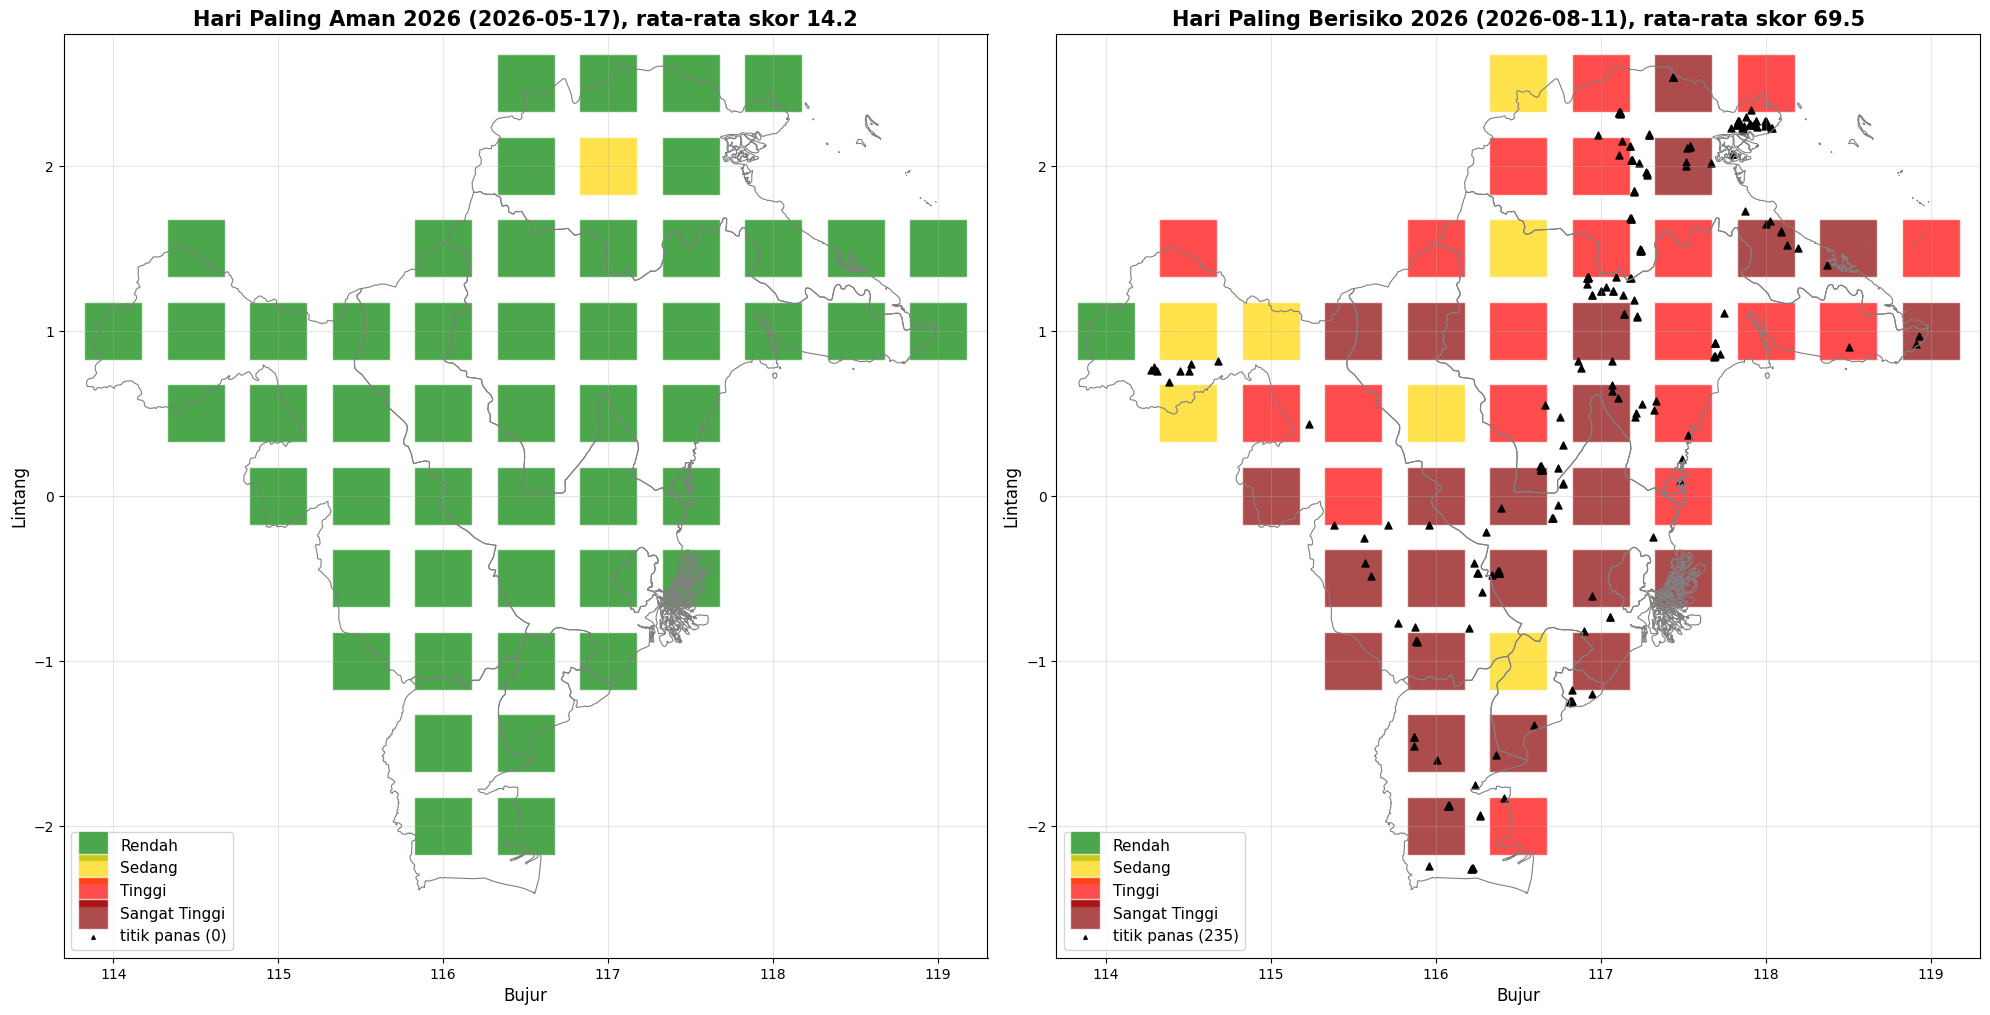

In [33]:
# peta risiko hari paling aman vs paling berisiko 2026
harian_all_2026 = cuaca[cuaca["tahun"] == 2026].groupby("tanggal")["skor_risiko"].mean()
tgl_rendah = harian_all_2026.idxmin()
warna_kelas = {"Rendah": "green", "Sedang": "gold", "Tinggi": "red", "Sangat Tinggi": "darkred"}

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, tgl, jdl in zip(axes, [tgl_rendah, tgl_puncak], ["Hari Paling Aman 2026", "Hari Paling Berisiko 2026"]):
    data_hari = cuaca[cuaca["tanggal"] == tgl]
    api_hari = firms[firms["tanggal"] == tgl]
    if "kaltim" in globals():
        kaltim.boundary.plot(ax=ax, color="gray", linewidth=0.8)
    for kelas, w in warna_kelas.items():
        d = data_hari[data_hari["kelas_risiko"] == kelas]
        ax.scatter(d["lon"], d["lat"], s=1800, marker="s", color=w, alpha=0.7, edgecolor="white", label=kelas)
    ax.scatter(api_hari["longitude"], api_hari["latitude"], s=25, color="black", marker="^",
               label=f"titik panas ({len(api_hari)})")
    ax.set_title(f"{jdl} ({tgl.date()}), rata-rata skor {data_hari['skor_risiko'].mean():.1f}",
                 fontsize=15, fontweight="bold")
    ax.set_xlim(113.7, 119.3)
    ax.set_ylim(-2.8, 2.8)
    ax.set_xlabel("Bujur", fontsize=12)
    ax.set_ylabel("Lintang", fontsize=12)
    ax.set_aspect("equal")
    ax.legend(fontsize=11, loc="lower left", markerscale=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### G3. Deret Harian Juli sampai September 2026
Membandingkan rata-rata skor risiko harian seluruh Kalimantan Timur dengan jumlah titik panas harian selama puncak musim kebakaran 2026. Garis putus-putus merah menandai batas kelas Tinggi (skor 50).

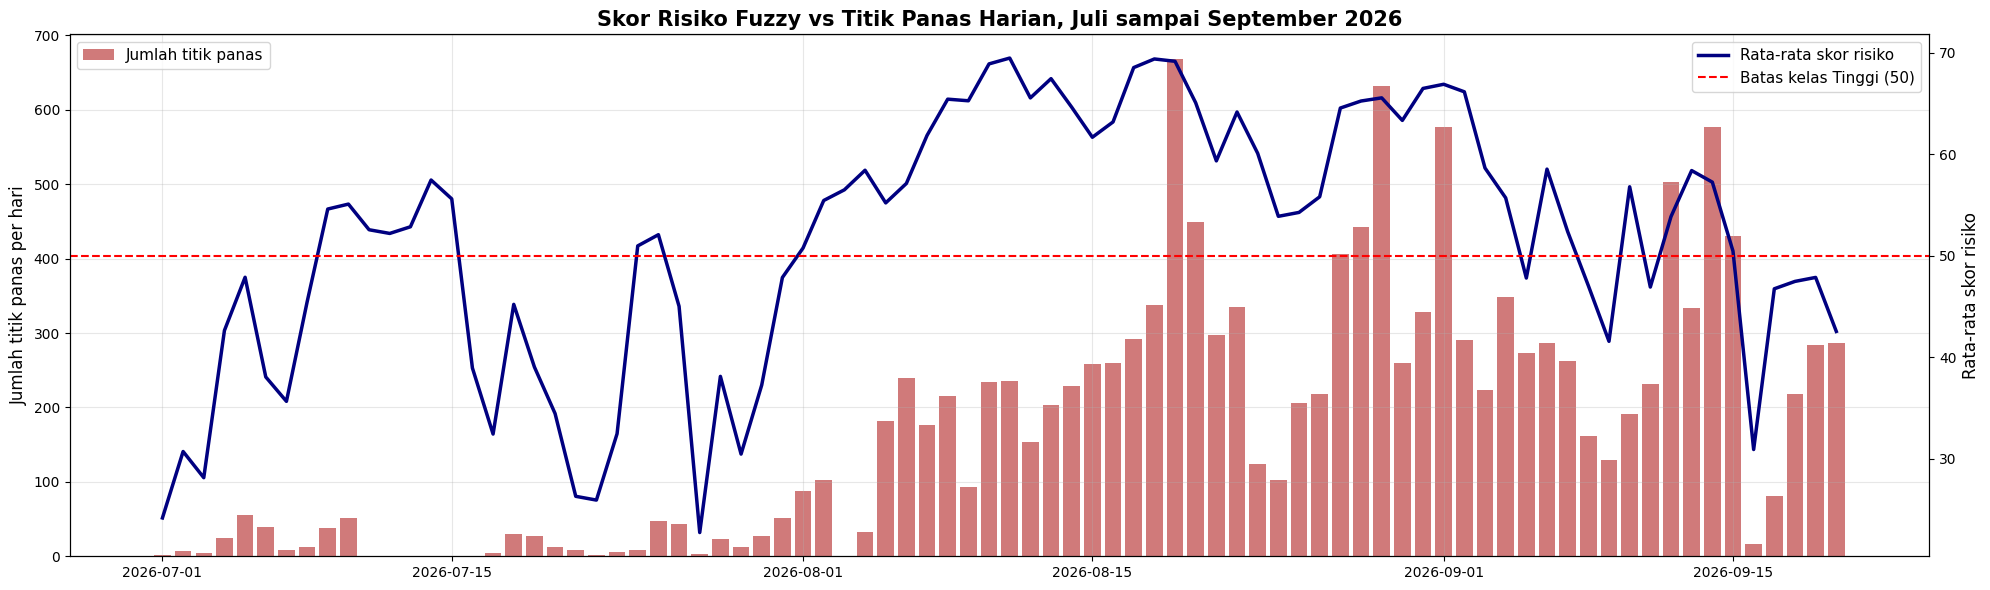

spearman harian Jul sampai Sep 2026: 0.657


In [34]:
# studi kasus harian juli sampai 20 september 2026
kasus = cuaca[cuaca["tanggal"] >= "2026-07-01"].groupby("tanggal").agg(
    skor=("skor_risiko", "mean"), api=("jumlah_titik_panas", "sum"))

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(kasus.index, kasus["api"], color="firebrick", alpha=0.6, label="Jumlah titik panas")
ax2 = ax.twinx()
ax2.plot(kasus.index, kasus["skor"], color="navy", linewidth=2.5, label="Rata-rata skor risiko")
ax2.axhline(50, color="red", linestyle="--", linewidth=1.5, label="Batas kelas Tinggi (50)")
ax.set_title("Skor Risiko Fuzzy vs Titik Panas Harian, Juli sampai September 2026", fontsize=15, fontweight="bold")
ax.set_ylabel("Jumlah titik panas per hari", fontsize=12)
ax2.set_ylabel("Rata-rata skor risiko", fontsize=12)
ax.legend(loc="upper left", fontsize=11)
ax2.legend(loc="upper right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("spearman harian Jul sampai Sep 2026:", round(kasus["skor"].corr(kasus["api"], method="spearman"), 3))

**Hasil G:**
Hari dengan rata-rata skor risiko tertinggi pada musim kebakaran 2026 adalah 11 Agustus 2026 (skor 69,5) dengan 235 titik panas, sedangkan hari paling aman adalah 17 Mei 2026 (skor 14,2) tanpa titik panas sama sekali. Pada hari paling berisiko, titik panas terkonsentrasi pada titik grid berkelas Tinggi dan Sangat Tinggi.

Secara harian, skor risiko mulai melampaui batas kelas Tinggi (skor 50) pada awal Agustus 2026 dan bertahan tinggi hingga pertengahan September. Lonjakan titik panas menyusul beberapa hari kemudian dan mencapai puncak pada 19 Agustus 2026 (668 titik panas). Korelasi Spearman harian selama Juli sampai September 2026 sebesar 0,657.

Pada pertengahan Juli, skor risiko sempat melampaui 50 tanpa diikuti lonjakan titik panas. Hal ini menunjukkan bahwa sistem mengukur potensi berdasarkan kondisi cuaca, sedangkan terjadinya kebakaran juga dipengaruhi faktor lain seperti lamanya bahan bakar mengering dan keberadaan sumber penyulutan.

## Kesimpulan

1. Sistem fuzzy Mamdani bertingkat dengan 5 variabel input (suhu maksimum, kelembapan minimum, curah hujan, kecepatan angin maksimum, dan hari tanpa hujan) dan 45 aturan berhasil menghasilkan skor risiko karhutla harian untuk 52 titik grid di Kalimantan Timur selama 1 Januari 2019 sampai 20 September 2026 (146.640 hari-grid).

2. Batas fungsi keanggotaan ditentukan secara hybrid, yaitu persentil data harian untuk suhu, kelembapan, curah hujan, dan angin, serta kategori BMKG untuk hari tanpa hujan. Ambang hujan 3 mm digunakan untuk mengatasi kecenderungan data ERA5 mencatat gerimis berlebihan di daerah tropis.

3. Validasi terhadap 57.105 titik panas NASA FIRMS menunjukkan pola yang konsisten: persentase hari-grid dengan titik panas meningkat dari 2,88% pada kelas Rendah, 8,96% pada kelas Sedang, 23,10% pada kelas Tinggi, hingga 57,22% pada kelas Sangat Tinggi. Titik panas pada kelas Sangat Tinggi muncul sekitar 20 kali lebih sering dibanding kelas Rendah.

4. Skor risiko rata-rata bulanan berkorelasi kuat dengan jumlah titik panas bulanan (Spearman 0,672), dengan puncak yang bertepatan pada musim kebakaran 2019, 2023, dan 2026.

5. Fuzzy Mamdani menghasilkan AUC 0,773, lebih tinggi dibandingkan metode if-else tegas dengan batas yang sama (0,706) dan metode hari tanpa hujan saja (0,670). Hal ini menunjukkan bahwa penalaran bertahap pada logika fuzzy memberikan nilai tambah dibandingkan logika tegas.

6. Sebagai sistem peringatan, kelas Tinggi dan Sangat Tinggi muncul pada 18,6% hari-grid, namun mampu mencakup 51,83% kejadian titik panas, dengan presisi 25,49% atau hampir tiga kali lipat dari peluang dasar (9,15%).

7. Studi kasus 2026 menunjukkan bahwa skor risiko meningkat melampaui kelas Tinggi pada awal Agustus, mendahului lonjakan titik panas yang memuncak pada 19 Agustus 2026, dengan korelasi Spearman harian 0,657.

**Keterbatasan dan saran pengembangan:**
- Sistem mengukur potensi risiko berdasarkan cuaca, belum memperhitungkan sumber penyulutan, jenis lahan, dan keberadaan gambut.
- Data ERA5 memiliki resolusi kasar dan nilai yang lebih halus dibanding pengukuran stasiun.
- Untuk penerapan sebagai peringatan dini, input data historis dapat diganti dengan data prakiraan cuaca sehingga risiko dapat diketahui beberapa hari sebelumnya.
- Penelitian lanjutan dapat menambahkan variabel gambut dan tutupan lahan, serta mengembangkan antarmuka web agar dapat digunakan oleh masyarakat dan petugas.